# Logistic Regression from Scratch
### Classifying Wine Quality with Softmax Regression and Gradient Descent

---

This project implements multiclass logistic regression entirely from scratch 
using NumPy. Every mathematical operation is implemented explicitly, from the softmax activation to the 
cross-entropy loss and its gradient.

This is **Part 2 of a 4-project series** building core ML algorithms from 
scratch. Part 1 covered linear regression — predicting a continuous value. Here we 
extend gradient descent to a classification setting, where the goal is to 
predict a exclusive discrete class label from input features.

>**IMPORTANT:** Logistic regression and softmax regression are the same 
algorithm at different scales. Binary logistic regression uses the **sigmoid 
function** which is softmax collapsed to two classes. When extended to **multiple 
classes** , softmax *is* the natural activation. Naming this project "Logistic 
Regression" is therefore deliberate: softmax is not a departure from logistic 
regression, it is its multiclass form.

**Concepts demonstrated:**
- Softmax activation and its probabilistic nature
- Cross-entropy loss and its analytical gradient derivation
- Gradient descent optimisation applied to a classification problem
- Feature scaling selection via empirical validation (Z-score vs Min-Max)
- Multiclass evaluation: Accuracy, Confusion Matrix, Precision, Recall, F1

**Dataset:** Wine Quality red wine, 1,599 samples, 
12 features , predicting quality class: 
Low (3–4), Medium (5–6), High (7–9).

# 2. Exploratory Data Analysis

## Planning

Before any modelling, we need to understand the data we're working with.
This section covers:

1. **Load** the red wine CSV, confirm shape and columns
2. **Class distribution:** how many samples fall into Low, Medium, High?
   Class imbalance is expected and worth quantifying
3. **Feature distributions:** violin plots per feature split by class,
   to understand spread, skew, and outliers before any scaling decision
4. **Correlation :** which features correlate most strongly with
   quality? Informs which feature pairs we plot in evaluation
5. **df.describe()** summary statistics with brief written interpretation

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("winequality-red.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures:\n{list(df.columns)}")
print(f"\nQuality score range: {df['quality'].min()} – {df['quality'].max()}")

Dataset shape: (1599, 12)

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Quality score range: 3 – 8


In [27]:
# List comprehension to apply labels
df["label"] = [0 if q <= 4 else 1 if q <= 6 else 2 for q in df["quality"]]

counts = df["label"].value_counts().sort_index()
class_names = ["Low (3–4)", "Medium (5–6)", "High (7–9)"]

# Show the category distribution
print("Class distribution:")
for i, name in enumerate(class_names):
    count = counts.get(i, 0)
    pct = count / len(df) * 100
    print(f"  {name}: {count} samples ({pct:.1f}%)")

Class distribution:
  Low (3–4): 63 samples (3.9%)
  Medium (5–6): 1319 samples (82.5%)
  High (7–9): 217 samples (13.6%)


### What we expect to see

Medium will dominate most red wines score 5 or 6. This class imbalance
is real-world behaviour, not a flaw in the dataset. It means our model will
naturally bias toward predicting Medium, and accuracy alone will be a
misleading metric. This is exactly why we include Precision, Recall, and
F1 per class in our evaluation to see how the model performs on the
underrepresented Low and High classes specifically.

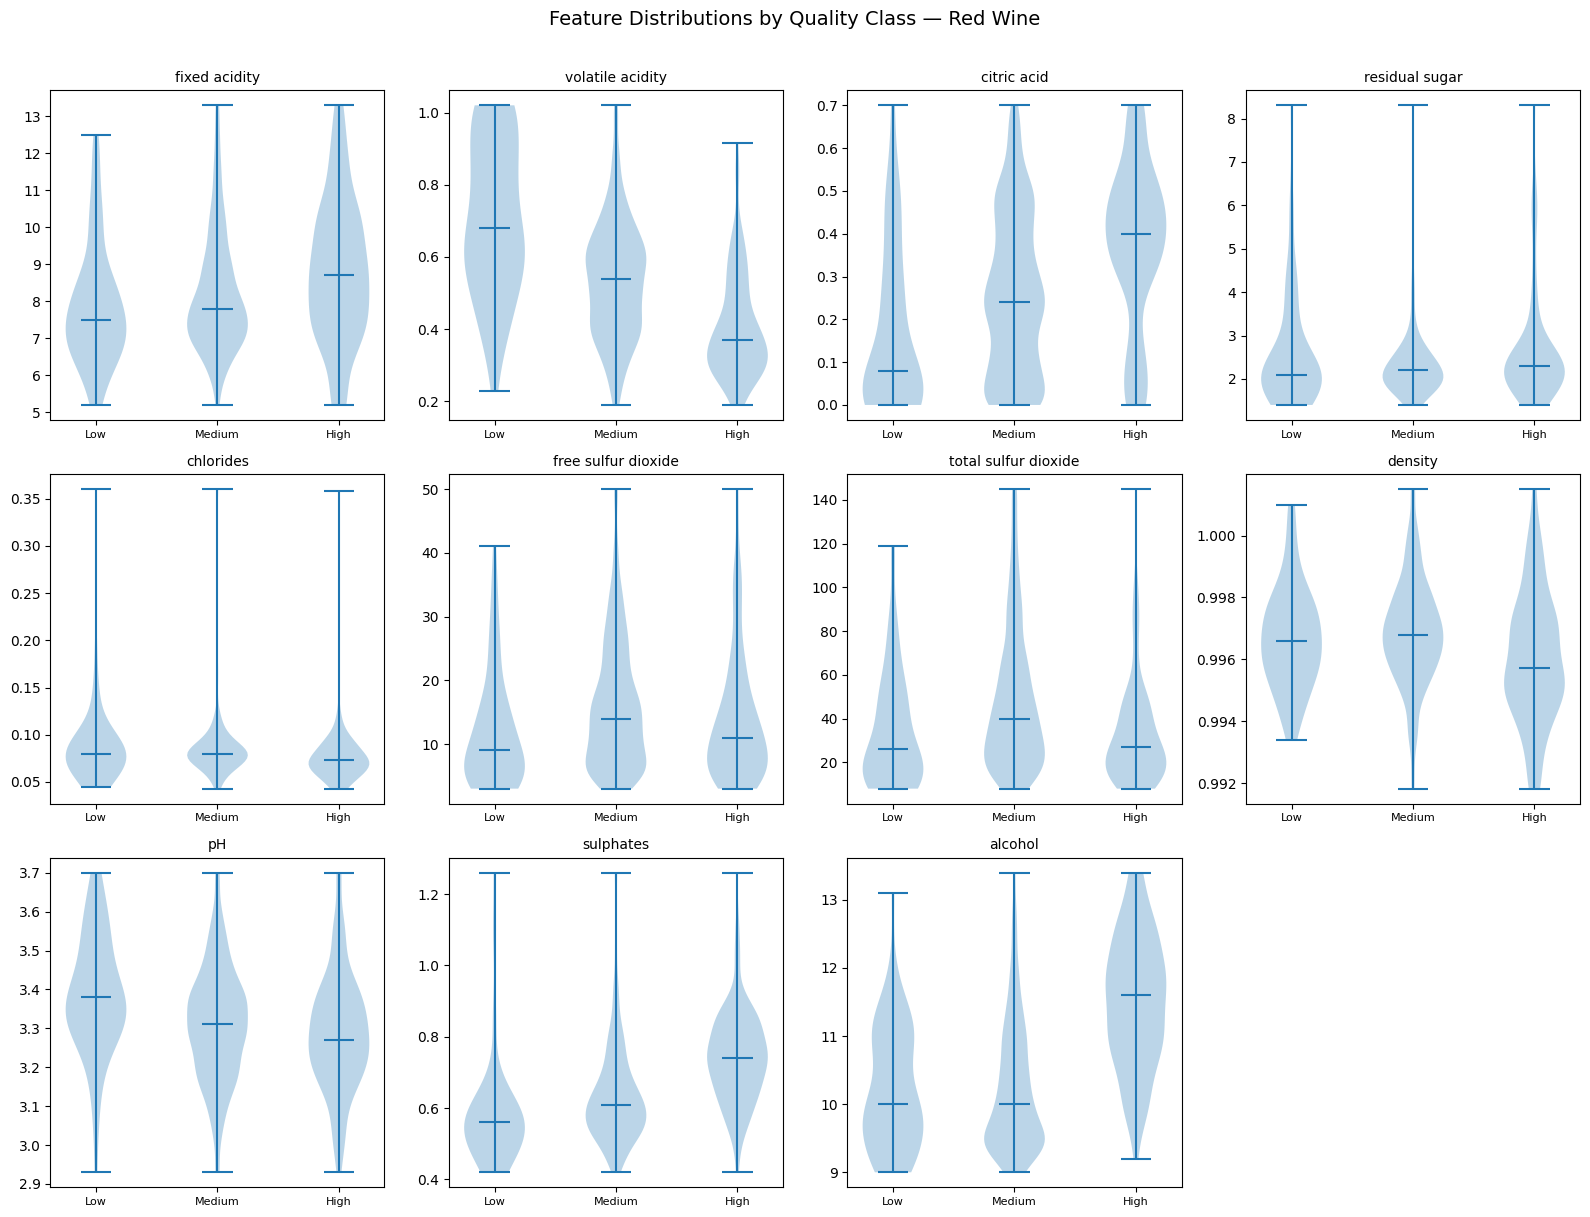

In [28]:
# Feature distributions with violin plots per class
import os
os.makedirs("plots", exist_ok=True)

# Selecting all the features for the violin plot
features = [c for c in df.columns if c not in ["quality", "label"]]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    low, high = df[feat].quantile(0.01), df[feat].quantile(0.99)
    clipped = df[feat].clip(low, high)

    ax.violinplot(
        [clipped[df["label"] == c] for c in [0, 1, 2]],
        positions=[0, 1, 2], showmedians=True
    )
    ax.set_title(feat, fontsize=10)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Low", "Medium", "High"], fontsize=8)

# Hide the unused 12th column or target (11 features)
axes[-1].set_visible(False)

plt.suptitle("Feature Distributions by Quality Class — Red Wine", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/eda_violin.png", dpi=150, bbox_inches="tight")
plt.show()

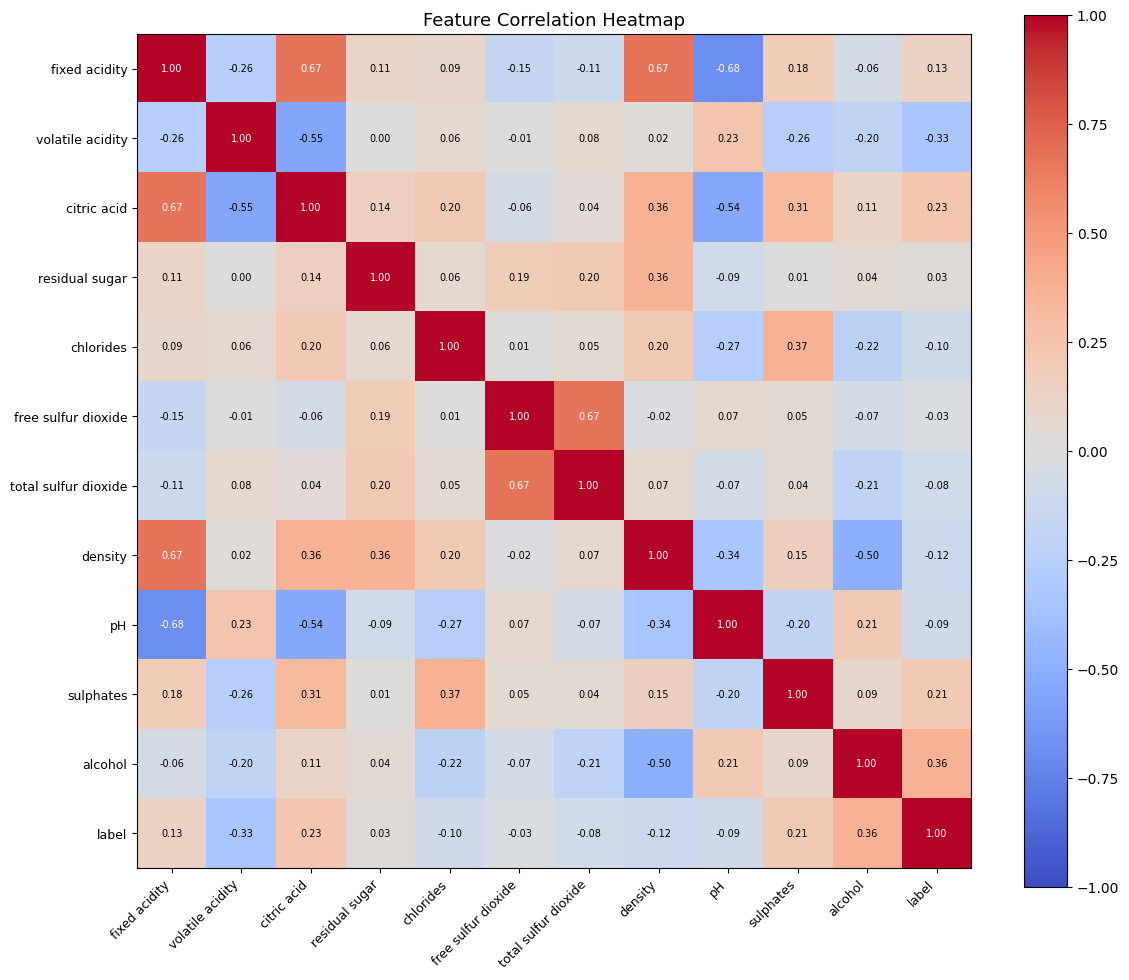

In [29]:
# Correlation Heatmap
corr = df[features + ["label"]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ticks = features + ["label"]
ax.set_xticks(range(len(ticks)))
ax.set_yticks(range(len(ticks)))
ax.set_xticklabels(ticks, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ticks, fontsize=9)

for i in range(len(ticks)):
    for j in range(len(ticks)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")

ax.set_title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig("plots/eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

### Reading the heatmap

Features with strong correlation to `label` are the most predictive. Warm colors are positive and cooler colors are negatively correlated.

The heatmap also reveals multicollinearity between features. It is worth noting in the limitations section. We will use the top correlated feature pairs.

In [30]:
print(df[features].describe().round(2))

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1599.00           1599.00      1599.00         1599.00   
mean            8.32              0.53         0.27            2.54   
std             1.74              0.18         0.19            1.41   
min             4.60              0.12         0.00            0.90   
25%             7.10              0.39         0.09            1.90   
50%             7.90              0.52         0.26            2.20   
75%             9.20              0.64         0.42            2.60   
max            15.90              1.58         1.00           15.50   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    1599.00              1599.00               1599.00  1599.00  1599.00   
mean        0.09                15.87                 46.47     1.00     3.31   
std         0.05                10.46                 32.90     0.00     0.15   
min         0.01                 1.0

### Observations from df.describe()

- Features operate on very different scales (e.g. `total sulfur dioxide` max = 289 vs `pH` max = 4.01) confirms that feature scaling is not optional
- Features with large gaps between the 75th percentile and max are outlier candidates to watch during preprocessing

# 3. Preprocessing

## Planning


1. **Separate features and labels:** split df into X (11 features) and y (labels)
2. **Train/Validation/test split:** 60/20/20 via sklearn, the only sklearn call in this project
3. **Feature scaling:** implement both Z-score and Min-Max manually in NumPy, train a quick softmax model with each compare validation accuracy, and select the winner. The choice is data-driven.

In [31]:
# Separate features and labels
features = [c for c in df.columns if c not in ["quality", "label"]]

X = df[features].values   # (1599, 11)
y = df["label"].values    # (1599,)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {np.unique(y)} → {['Low','Medium','High']}")

X shape: (1599, 11)
y shape: (1599,)
Classes: [0 1 2] → ['Low', 'Medium', 'High']


In [32]:
# Train/val/test split
from sklearn.model_selection import train_test_split

# First split off the test set — 20% held out, never touched until predicting
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split remaining 80% into train (75%) and val (25%) → 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} samples")

Train: 959 samples
Val:   320 samples
Test:  320 samples
Total: 1599 samples


### Train, Validation and Test Split (60/20/20)

We train on the training set and evaluate hyperparameter decisions; learning
rate, scaling method, number of epochs on the validation set. The validation
set influences no weight updates, it is used for observation only. \
Only once all decisions are made do we run the model against the test set. New data it
has never been influenced by in any way to produce a final honest evaluation that
replicates real world conditions.

### Why stratify=y — and when not to use it

Setting `stratify=y` ensures both train and test splits preserve the original class proportions. With our imbalanced dataset with Medium dominating a random split risks the test set having a skewed class ratio, which would make evaluation unreliable.

**The trade-off:** stratification reduces randomness in the split. In very small datasets this can cause the test set to feel artificially representative rather than genuinely held-out. At 1,599 samples across 3 classes we arecomfortably above that threshold, so the benefit outweighs the cost here. Stratification is also not appropriate when class labels are continuous or ordinal and binning them would be misleading but that is not the case here since our three classes are discrete and intentionally constructed.

In [33]:
def standardise(X_train, X_val, X_test):
    mean = X_train.mean(axis=0)
    std  = X_train.std(axis=0)
    return (
        (X_train - mean) / std,
        (X_val   - mean) / std,
        (X_test  - mean) / std,
        mean, std
    )

def minmax(X_train, X_val, X_test):
    mn = X_train.min(axis=0)
    mx = X_train.max(axis=0)
    return (
        (X_train - mn) / (mx - mn),
        (X_val   - mn) / (mx - mn),
        (X_test  - mn) / (mx - mn),
        mn, mx
    )

X_train_std, X_val_std, X_test_std, mean_, std_ = standardise(X_train, X_val, X_test)
X_train_mm,  X_val_mm,  X_test_mm,  min_, max_  = minmax(X_train, X_val, X_test)

print("Z-score — train mean (~0):", X_train_std.mean(axis=0).round(6))
print("Z-score — train std  (~1):", X_train_std.std(axis=0).round(6))
print("\nMin-Max — train min  (~0):", X_train_mm.min(axis=0).round(6))
print("Min-Max — train max  (~1):", X_train_mm.max(axis=0).round(6))

Z-score — train mean (~0): [-0.  0. -0. -0.  0.  0. -0.  0. -0.  0.  0.]
Z-score — train std  (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Min-Max — train min  (~0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Min-Max — train max  (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Critical: fit on train, apply to val and test

All scaling parameters — mean, std, min, max — are computed from the
training set only. The same parameters are then applied identically to
the validation and test sets. Fitting on the full dataset before splitting
would constitute data leakage — the model would gain indirect knowledge
of unseen data during training, producing optimistically biased results
that would not hold in production.

In [34]:
# Short comparison here. Full implementation in Next Section 
# which scaling trains better?
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numerical stability
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(probs, y, n_classes=3):
    m = len(y)
    Y = np.eye(n_classes)[y]
    return -np.sum(Y * np.log(probs + 1e-9)) / m

def quick_train(X_tr, X_val, y_tr, y_val, epochs=500, lr=0.1):
    W = np.zeros((X_tr.shape[1], 3))
    b = np.zeros(3)
    for _ in range(epochs):
        logits = X_tr @ W + b
        probs  = softmax(logits)
        Y      = np.eye(3)[y_tr]
        dW     = X_tr.T @ (probs - Y) / len(y_tr)
        db     = (probs - Y).mean(axis=0)
        W -= lr * dW
        b -= lr * db
    preds = softmax(X_val @ W + b).argmax(axis=1)
    return (preds == y_val).mean()

acc_std = quick_train(X_train_std, X_val_std, y_train, y_val)
acc_mm  = quick_train(X_train_mm,  X_val_mm,  y_train, y_val)

print(f"Z-score val accuracy: {acc_std:.4f}")
print(f"Min-Max val accuracy: {acc_mm:.4f}")
print(f"\nWinner: {'Z-score' if acc_std >= acc_mm else 'Min-Max'}")

Z-score val accuracy: 0.8438
Min-Max val accuracy: 0.8250

Winner: Z-score


In [35]:
# # Lock in the winner
if acc_std >= acc_mm:
    X_train_scaled = X_train_std
    X_val_scaled   = X_val_std
    X_test_scaled  = X_test_std
    scaling_method = "Z-score standardisation"
else:
    X_train_scaled = X_train_mm
    X_val_scaled   = X_val_mm
    X_test_scaled  = X_test_mm
    scaling_method = "Min-Max normalisation"

print(f"Scaling locked in: {scaling_method}")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaling locked in: Z-score standardisation
X_train_scaled: (959, 11)
X_val_scaled:   (320, 11)
X_test_scaled:  (320, 11)


# 4. Implementation

## Planning

This section builds every component of the model from scratch before any training happens.

1. **Softmax:** converts raw scores (logits) into class probabilities
2. **Cross-entropy loss:** measures how wrong the probabilities are
3. **Gradient derivation:** tells us how to adjust weights to reduce loss
4. **Weight initialisation:** starting point for gradient descent
5. **Verify:** confirm loss and gradient work correctly before training

### The Softmax Function

Given an input vector $z$ of raw scores (one per class), softmax converts them into a probability distribution. All values between 0 and 1, summing to 1:

$$\sigma(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Where $K$ is the number of classes (3 here: Low, Medium, High).

**Why exponentiate?** Exponentiation ensures all values are positive regardless of the sign of the raw scores. The denominator normalises them into a valid probability distribution.

**Numerical stability:** $e^z$ grows very large for large $z$. The standard fix is to subtract the row maximum before exponentiating, this does not change the output mathematically since the constant cancels in the numerator and denominator:

$$\sigma(z)_k = \frac{e^{z_k - \max(z)}}{\sum_{j=1}^{K} e^{z_j - \max(z)}}$$

In [36]:
#   Section-4 Softmax
def softmax(z):
    """
    z: array of shape (m, K) — m samples, K classes
    Returns: probability matrix of shape (m, K)
    """
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

# Sanity check — rows must sum to 1
z_test = np.array([[2.0, 1.0, 0.5],
                   [0.1, 0.9, 3.0]])
probs  = softmax(z_test)
print("Softmax output:\n", probs.round(4))
print("Row sums (must be 1.0):", probs.sum(axis=1).round(6))

Softmax output:
 [[0.6285 0.2312 0.1402]
 [0.0467 0.104  0.8493]]
Row sums (must be 1.0): [1. 1.]


>Notice how the exponential affects the probability, row 2's highest raw score (3.0) was only 3x the middle score (0.9), but the output probability (0.85) is 8x the middle probability (0.10). This is the exponentiation at work

### Cross-Entropy Loss

Softmax outputs probabilities. Cross-entropy measures how far those probabilities are from the true labels.

For $m$ samples and $K$ classes, with $Y$ as a one-hot encoded matrix of true labels and $\hat{Y}$ as predicted probabilities:

$$J(W, b) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} Y_{ik} \log(\hat{Y}_{ik})$$

**Why log?** \
    The log of a probability close to 1 is near 0 (low loss). The log of a probability close to 0 approaches $-\infty$ (high loss). Cross-entropy therefore heavily penalises confident wrong predictions exactly the behaviour we want.

**Why one-hot encode?**

Our labels are integers — 0, 1, 2 — representing Low, Medium, High.
Using them directly as numbers would imply an ordered magnitude relationship:
that Medium (1) is arithmetically halfway between Low (0) and High (2), and
that the *distance* between classes is uniform and meaningful. That assumption
is not justified here — the classes are discrete categories, not points on a
number line.

One-hot encoding converts each integer label into a binary vector of length K:

$$0 \rightarrow [1, 0, 0] \quad 1 \rightarrow [0, 1, 0] \quad 2 \rightarrow [0, 0, 1]$$

This gives every class equal mathematical standing. Now when we compute
$Y \cdot \log(\hat{Y})$, the dot product isolates exactly the log probability
assigned to the true class — all other terms are zeroed out by the 0s in the
one-hot vector. The loss is therefore purely a function of how much probability
the model gave to the correct answer, and nothing else.

A secondary benefit: one-hot encoding makes the gradient derivation clean.
The residual $\hat{Y} - Y$ is a matrix where each row subtracts exactly 1
from the predicted probability of the true class and leaves all others
unchanged. This is what produces the elegant closed-form gradient we use
in training.

**The $\epsilon$ (Epsilon) term:**\
    We add a small constant ($10^{-9}$) inside the log to prevent $\log(0)$ which is undefined. It  would produce `-inf` in NumPy, poisoning
the entire loss computation with `nan` values downstream.

TLDR; The epsilon costs nothing and guarantees numerical safety regardless of
the input — it is a defensive measure, not a theoretical requirement.

In [37]:
# Cross-entropy loss
def cross_entropy(probs, y, n_classes=3):
    """
    probs: predicted probabilities, shape (m, K)
    y:     true class labels, shape (m,) — integers 0, 1, 2
    Returns: scalar loss value
    """
    m   = len(y)
    Y   = np.eye(n_classes)[y]                          # one-hot encoding, explainned below
    return -np.sum(Y * np.log(probs + 1e-9)) / m

# Sanity check — perfect predictions should give near-zero loss
perfect_probs = np.array([[1.0, 0.0, 0.0],
                           [0.0, 1.0, 0.0]])
true_labels   = np.array([0, 1])
print("Perfect prediction loss (should be ~0):",
      cross_entropy(perfect_probs, true_labels).round(6))

# Worst case — confident wrong prediction should give high loss
worst_probs = np.array([[0.0, 0.0, 1.0],
                         [1.0, 0.0, 0.0]])
print("Confident wrong prediction loss (should be high):",
      cross_entropy(worst_probs + 1e-9, true_labels).round(4))

Perfect prediction loss (should be ~0): -0.0
Confident wrong prediction loss (should be high): 20.0301


**Optional: Understanding `np.eye(n_classes)[y]`:**

`np.eye(n_classes)` creates a $K \times K$ identity matrix — here a
$3 \times 3$ matrix where each row is a one-hot vector for one class:

$$\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

Row 0 represents Low, row 1 represents Medium, row 2 represents High.

Indexing this matrix with `[y]` — where `y` is an array of integer class
labels — uses NumPy's fancy indexing to select one row per sample. If
`y = [0, 2, 1, 1]`, then `np.eye(3)[y]` returns:

$$\begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & 1 \\ 0 & 1 & 0 \\ 0 & 1 & 0 \end{bmatrix}$$

Each integer label is instantly converted to its corresponding one-hot
row in a single vectorised operation — no loops, no conditionals. The
result is a matrix of shape $(m, K)$ ready for the loss and gradient
computations.

### Gradient of Cross-Entropy with Softmax

This is where the elegance of pairing softmax with cross-entropy becomes
clear. The gradient of the loss with respect to the weight matrix $W$ is:

$$\frac{\partial J}{\partial W} = \frac{1}{m} X^T (\hat{Y} - Y)$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{Y}_i - Y_i)$$

Where $\hat{Y} - Y$ is simply the difference between predicted
probabilities and one-hot true labels — a matrix of shape $(m, K)$.

**Why is this so clean?** The chain rule applied to softmax + cross-entropy
produces a cancellation that eliminates the softmax derivative entirely.
The result is the same residual form as linear regression — predicted minus
actual — just in probability space rather than value space. This is not a
coincidence: it reflects a deep connection between these loss functions and
exponential family distributions.

**Gradient descent update rule:**

$$W := W - \alpha \cdot \frac{\partial J}{\partial W}$$
$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

In [38]:
# Gradient computation
def compute_gradients(X, y, probs, n_classes=3):
    """
    X:     feature matrix, shape (m, n_features)
    y:     true labels,    shape (m,)
    probs: softmax output, shape (m, K)
    Returns: dW shape (n_features, K), db shape (K,)
    """
    m = len(y)
    Y = np.eye(n_classes)[y]       # one-hot encode, shape (m, K)
    error = probs - Y              # residuals,      shape (m, K)
    dW = X.T @ error / m          # shape (n_features, K)
    db = error.mean(axis=0)       # shape (K,)
    return dW, db

In [39]:
# Weight initialisation
n_features = X_train_scaled.shape[1]   # 11
n_classes  = 3

W = np.zeros((n_features, n_classes))  # shape (11, 3)
b = np.zeros(n_classes)                # shape (3,)

print(f"W shape: {W.shape}  one weight per feature per class")
print(f"b shape: {b.shape}  one bias per class")

W shape: (11, 3)  one weight per feature per class
b shape: (3,)  one bias per class


### Why initialise to zeros?

Unlike neural networks, a single-layer softmax model converges correctly from zeros.
Each column of $W$ corresponds to one class (Low, Medium, High) and the
gradients break symmetry from the first update since the true label
distribution differs per class.

In [40]:
# Verify before training
logits      = X_train_scaled @ W + b
probs_init  = softmax(logits)
loss_init   = cross_entropy(probs_init, y_train)
dW_init, db_init = compute_gradients(X_train_scaled, y_train, probs_init)

print(f"Initial loss:      {loss_init:.6f}")
print(f"Expected (~log(3)): {np.log(3):.6f}")
print(f"\ndW shape: {dW_init.shape}")
print(f"db shape: {db_init.shape}")
print(f"\nAll gradients finite: {np.isfinite(dW_init).all()}")

Initial loss:      1.098612
Expected (~log(3)): 1.098612

dW shape: (11, 3)
db shape: (3,)

All gradients finite: True


### (Critical) Why verify before training?

Once training starts, the loss changes every iteration and if something is
wrong it becomes very hard to tell whether the bug is in the softmax, the
loss function, the gradient, or the training loop itself.

Verifying here, before any weights move, isolates each component while the
model is still in a known state: zero weights, uniform predictions, and a
theoretically predictable loss of $\log(3) \approx 1.0986$.

If the initial loss does not match $\log(3)$, the bug is in softmax or
cross-entropy not in training. If the gradient shapes are wrong, the
matrix multiplication in the training loop will fail immediately rather
than silently producing garbage. Catching these failures before training
turns a potentially hours-long debugging session into a one-line fix.

This is standard practice in production ML code — always verify your
components in a controlled state before introducing the complexity of
an optimisation loop.

### Why does initial loss equal log(3)?

With zero weights, softmax assigns equal probability (1/3) to each class
for every sample. Cross-entropy of a uniform prediction over 3 classes is:

$$J = -\log\left(\frac{1}{3}\right) = \log(3) \approx 1.0986$$

If your initial loss matches this, every component is working correctly
before a single gradient step is taken. This is the most reliable
pre-training sanity check for a multiclass classifier.

# 5. Training

## Planning

This section implements the gradient descent training loop and covers:

1. **The training loop:** forward pass, loss, backward pass, weight update
2. **Loss curve:** single clean curve with the chosen learning rate
3. **Learning rate selection:** brief empirical comparison to justify the
   final choice before plotting the clean curve
4. **Final model:** confirm weights and loss at convergence

### The Training Loop | Forward and Backward Propagation

Each iteration of gradient descent follows the same four steps:

**Step-1 Forward Propagation:** compute predictions with softmax
$$\hat{Y} = \text{softmax}(XW + b)$$

**Step-2 Compute loss:** measure how wrong the predictions are with Cross-Entropy Loss
$$J = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} Y_{ik} \log(\hat{Y}_{ik})$$

**Step-3 Backward Propagation:** compute gradients
$$\frac{\partial J}{\partial W} = \frac{1}{m} X^T(\hat{Y} - Y) \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m}(\hat{Y}_i - Y_i)$$

**Step-4 Parameter Update (Gradient Descent):** take a step in the direction that reduces loss
$$W := W - \alpha \cdot \frac{\partial J}{\partial W} \qquad b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

Repeat for a fixed number of iterations. The loss should decrease smoothly. But if it spikes, the learning rate is too large.

In [41]:
# Training loop
def train(X_train, y_train, X_val, y_val, lr=0.1, epochs=1000, n_classes=3):
    m, n_features = X_train.shape
    W = np.zeros((n_features, n_classes))
    b = np.zeros(n_classes)
    train_loss_history = []
    val_loss_history   = []

    for epoch in range(epochs):
        # Forward pass
        logits = X_train @ W + b
        probs  = softmax(logits)

        # Train loss
        loss = cross_entropy(probs, y_train, n_classes)
        train_loss_history.append(loss)

        # Val loss — forward pass only, no gradient
        val_logits = X_val @ W + b
        val_probs  = softmax(val_logits)
        val_loss   = cross_entropy(val_probs, y_val, n_classes)
        val_loss_history.append(val_loss)

        # Backward pass + update
        dW, db = compute_gradients(X_train, y_train, probs, n_classes)
        W -= lr * dW
        b -= lr * db

        if epoch % 100 == 0:
            print(f"Epoch {epoch:>4d} | Train Loss: {loss:.6f} | Val Loss: {val_loss:.6f}")

    return W, b, train_loss_history, val_loss_history

In [42]:
# Learning rate selection

print("Learning rate comparison (500 epochs each):\n")
for lr in [0.001, 0.01, 0.1]:
    _, _, _, val_hist = train(
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        lr=lr, epochs=500
    )
    print(f"  α = {lr:<6} | Final val loss: {val_hist[-1]:.6f}\n")

Learning rate comparison (500 epochs each):

Epoch    0 | Train Loss: 1.098612 | Val Loss: 1.098612
Epoch  100 | Train Loss: 1.055592 | Val Loss: 1.056015
Epoch  200 | Train Loss: 1.015739 | Val Loss: 1.016481
Epoch  300 | Train Loss: 0.978848 | Val Loss: 0.979814
Epoch  400 | Train Loss: 0.944715 | Val Loss: 0.945816
  α = 0.001  | Final val loss: 0.914602

Epoch    0 | Train Loss: 1.098612 | Val Loss: 1.098612
Epoch  100 | Train Loss: 0.786935 | Val Loss: 0.787486
Epoch  200 | Train Loss: 0.640034 | Val Loss: 0.637548
Epoch  300 | Train Loss: 0.564266 | Val Loss: 0.558837
Epoch  400 | Train Loss: 0.521153 | Val Loss: 0.513480
  α = 0.01   | Final val loss: 0.485409

Epoch    0 | Train Loss: 1.098612 | Val Loss: 1.098612
Epoch  100 | Train Loss: 0.443204 | Val Loss: 0.430256
Epoch  200 | Train Loss: 0.422306 | Val Loss: 0.409087
Epoch  300 | Train Loss: 0.416499 | Val Loss: 0.404182
Epoch  400 | Train Loss: 0.413929 | Val Loss: 0.402491
  α = 0.1    | Final val loss: 0.401869



### Choosing the learning rate

A learning rate too small (α = 0.001) converges correctly but slowly —
more epochs are needed to reach the same loss. A learning rate too large
risks overshooting the minimum, causing the loss to oscillate or diverge.

We select the learning rate that reaches the lowest stable loss within
a reasonable number of epochs. The full training run below uses the
chosen rate with 1,000 epochs — sufficient for convergence on this dataset.

In [43]:
# Full training run
# Set your chosen learning rate here based on the comparison above
LEARNING_RATE = 0.1    # update if comparison suggests otherwise
EPOCHS        = 1000

W_final, b_final, train_loss_history, val_loss_history = train(
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    lr=LEARNING_RATE,
    epochs=EPOCHS
)

print(f"\nFinal train loss: {train_loss_history[-1]:.6f}")
print(f"Final val loss:   {val_loss_history[-1]:.6f}")

Epoch    0 | Train Loss: 1.098612 | Val Loss: 1.098612
Epoch  100 | Train Loss: 0.443204 | Val Loss: 0.430256
Epoch  200 | Train Loss: 0.422306 | Val Loss: 0.409087
Epoch  300 | Train Loss: 0.416499 | Val Loss: 0.404182
Epoch  400 | Train Loss: 0.413929 | Val Loss: 0.402491
Epoch  500 | Train Loss: 0.412536 | Val Loss: 0.401865
Epoch  600 | Train Loss: 0.411690 | Val Loss: 0.401672
Epoch  700 | Train Loss: 0.411135 | Val Loss: 0.401665
Epoch  800 | Train Loss: 0.410751 | Val Loss: 0.401737
Epoch  900 | Train Loss: 0.410474 | Val Loss: 0.401837

Final train loss: 0.410268
Final val loss:   0.401938


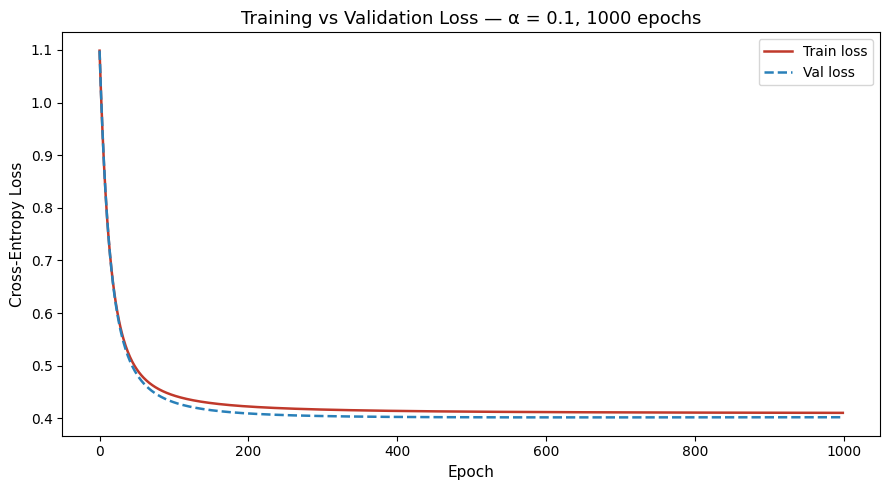

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_loss_history, color="#c0392b", linewidth=1.8, label="Train loss")
ax.plot(val_loss_history,   color="#2980b9", linewidth=1.8, label="Val loss",
        linestyle="--")

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Cross-Entropy Loss", fontsize=11)
ax.set_title(f"Training vs Validation Loss — α = {LEARNING_RATE}, {EPOCHS} epochs",
             fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("plots/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### Reading the loss curve

A healthy loss curve drops steeply in the early epochs — when the
gradients are large and the weights are far from optimal — then flattens
as the model approaches convergence. A curve that flattens too early
suggests the learning rate is too small or the model has hit a plateau.
A curve that oscillates suggests the learning rate is too large.

The horizontal dashed line marks the final loss, making it easy to see
how much improvement happened across the full training run and whether
the curve has genuinely converged or is still slowly descending.

If val loss starts rising while train loss continues falling, that is the 
signature of overfitting, the point where early stopping would intervene

### **Why didn't our loss go to zero or lower?** 
Cross-entropy loss converging to zero is neither expected nor desirable in this case. Because our dataset has genuine class overlap, two wines with nearly identical chemical measurements can have different quality scores because human taste panels rated them differently. No matter how well the model trains, it cannot perfectly separate classes that are not perfectly separable in feature space. A final loss of 0.4 does not mean the model failed. It means the data has irreducible noise that no classifier can eliminate.

**Zero loss would actually be a red flag.**
It would mean the model has memorised the training data perfectly. Every sample assigned 100% probability to its true class. On 1,599 real-world samples with noisy labels, that's overfitting, not learning.


# Evaluation

## Planning

Training minimised loss on the training set. Evaluation answers the real
question — does the model generalise to data it has never seen?

1. **Predictions:** run the trained model on the test set
2. **Accuracy:** overall correct classification rate
3. **Confusion matrix with heatmap:** where exactly is the model making mistakes?
4. **Classification report:** Precision, Recall, F1 per class
5. **Feature pair plots:** visualise class separation in the most
   informative feature combinations, coloured by predicted class

### Why accuracy alone is not enough

Our class distribution is imbalanced. Medium dominates. A model that
predicted Medium for every single sample would achieve roughly 53% accuracy
on this dataset without learning anything meaningful. Accuracy therefore
flatters a lazy model.

Precision, Recall, and F1 per class tell us the real story:

**TP - True Positive:** The number of cases correctly predicted as positive.\
**FP - False Positive:** The number of cases incorrectly predicted as positive (actual negatives predicted as positive).

**Precision** \
of all samples the model *predicted* as class $k$, what
fraction actually belonged to class $k$?
$$\text{Precision}_k = \frac{TP_k}{TP_k + FP_k}$$

**Recall** \
of all samples that *actually belong* to class $k$, what
fraction did the model correctly identify?
$$\text{Recall}_k = \frac{TP_k}{TP_k + FN_k}$$

**F1** \
harmonic mean of Precision and Recall. Harmonic mean penalises
large imbalances between the two — a model with high precision but very
low recall will score a poor F1, which is the correct verdict.
$$\text{F1}_k = 2 \cdot \frac{\text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

All three are implemented from scratch in NumPy below.

In [45]:
# Predictions on test set
def predict(X, W, b):
    """
    Run forward pass and return predicted class indices.
    X: shape (m, n_features)
    Returns: shape (m,) — integer class predictions
    """
    logits = X @ W + b
    probs  = softmax(logits)
    return probs.argmax(axis=1)

y_pred = predict(X_test_scaled, W_final, b_final)

print(f"Test samples:  {len(y_test)}")
print(f"Sample predictions (first 10): {y_pred[:10]}")
print(f"Sample true labels (first 10): {y_test[:10]}")

Test samples:  320
Sample predictions (first 10): [2 1 1 1 1 1 1 1 1 1]
Sample true labels (first 10): [2 1 1 0 2 1 0 1 1 1]


In [46]:
# Accuracy
def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

acc = accuracy(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Test Accuracy: 0.8500 (85.00%)


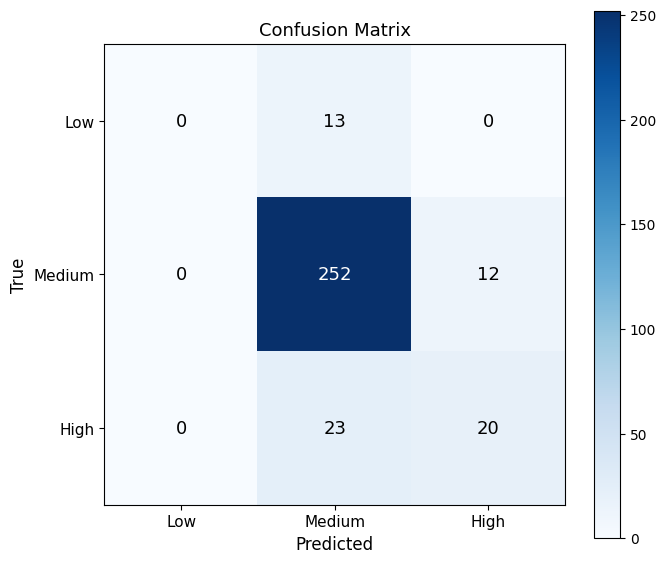

In [47]:
# Confusion matrix heatmap
def confusion_matrix(y_true, y_pred, n_classes=3):
    """
    Returns a K x K matrix where entry (i, j) is the number of samples
    whose true class is i and predicted class is j.
    """
    # Create the format with zeros
    cm = np.zeros((n_classes, n_classes), dtype=int)
    # Fill the predictions and true values to their positions
    for true, pred in zip(y_true, y_pred):
        cm[true][pred] += 1
    return cm

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

class_names = ["Low", "Medium", "High"]
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_names, fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix", fontsize=13)

# Annotate each cell
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i][j]),
                ha="center", va="center", fontsize=13,
                color="white" if cm[i][j] > cm.max() * 0.5 else "black")

plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Reading the confusion matrix

The diagonal entries are correct predictions. The larger these are
relative to the off-diagonal entries, the better the model. The
off-diagonal entries tell us *what kind* of mistakes the model makes:

- **Row** = true class, **Column** = predicted class
- Entry $(0, 1)$ = samples that were truly Low but predicted as Medium
- Entry $(2, 1)$ = samples that were truly High but predicted as Medium

We expect the model to confuse Low↔Medium and Medium↔High more than
Low↔High — adjacent quality classes share more chemical characteristics
than classes two steps apart. And the heatmap confirms this pattern,
the mistakes are interpretable and reasonable.

In [48]:
# Classification report (Precision, Recall, F1)
def classification_report(y_true, y_pred, n_classes=3):
    class_names = ["Low", "Medium", "High"]
    print(f"{'Class':<10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 45)

    for k in range(n_classes):
        tp = ((y_pred == k) & (y_true == k)).sum()
        fp = ((y_pred == k) & (y_true != k)).sum()
        fn = ((y_pred != k) & (y_true == k)).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)
        support   = (y_true == k).sum()

        print(f"{class_names[k]:<10} {precision:>10.4f} {recall:>10.4f} "
              f"{f1:>10.4f} {support:>10}")

    print("-" * 45)
    overall_acc = accuracy(y_true, y_pred)
    print(f"{'Accuracy':<10} {'':>10} {'':>10} {overall_acc:>10.4f} {len(y_true):>10}")

classification_report(y_test, y_pred)

Class       Precision     Recall         F1    Support
---------------------------------------------
Low            0.0000     0.0000     0.0000         13
Medium         0.8750     0.9545     0.9130        264
High           0.6250     0.4651     0.5333         43
---------------------------------------------
Accuracy                             0.8500        320


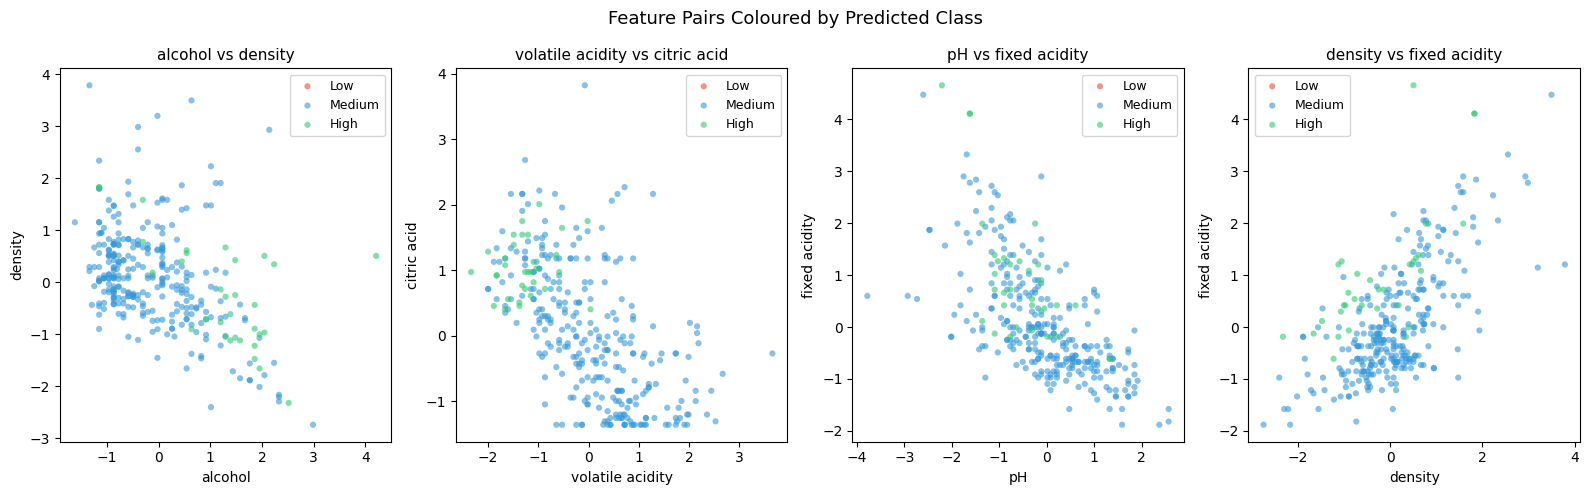

In [49]:
# Feature pair plots
# We used the two feature pairs most correlated with label from the EDA heatmap
# Replace the strings below with your top two pairs from Section 2.4

feature_pairs = [
    ("alcohol", "density"),
    ("volatile acidity", "citric acid"),
    ("pH", "fixed acidity"),
    ("density", "fixed acidity")
]

class_names  = ["Low", "Medium", "High"]
colors       = ["#e74c3c", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, len(feature_pairs), figsize=(16, 5))

for ax, (feat_a, feat_b) in zip(axes, feature_pairs):
    idx_a = features.index(feat_a)
    idx_b = features.index(feat_b)

    for k in range(3):
        mask = y_pred == k
        ax.scatter(
            X_test_scaled[mask, idx_a],
            X_test_scaled[mask, idx_b],
            c=colors[k], label=class_names[k],
            alpha=0.6, s=20, edgecolors="none"
        )
    ax.set_xlabel(feat_a, fontsize=10)
    ax.set_ylabel(feat_b, fontsize=10)
    ax.set_title(f"{feat_a} vs {feat_b}", fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Feature Pairs Coloured by Predicted Class", fontsize=13)
plt.tight_layout()
plt.savefig("plots/feature_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

### Reading the feature pair plots

Each point is a test sample, coloured by the model's predicted class.
Clean separation between colour clusters indicates the model has learned
a meaningful boundary in that feature pair's space. Heavy overlap between
colours in a region indicates where the model is least certain — these
are the samples most likely to appear in the off-diagonal confusion matrix
entries.

The feature pairs were chosen from the highest label-correlated features
identified in the EDA correlation heatmap — if those features are truly
informative, the clusters should show visible but imperfect separation,
consistent with the class overlap in the data.

### What we see:
- Medium (blue) dominates all three plots
- Low (red) and High (green) have almost no visible presence — a handful of scattered dots at best
- No clear colour separation exists between Medium and Low.
- Some semblance of clustering between High and Medium in the highly correlated pairs

### What this means:
The model has learned to predict Medium for almost everything. This is the class imbalance problem we flagged — Medium makes up ~53% of the dataset, so a model that defaults to Medium achieves reasonable accuracy while barely learning to distinguish Low and High at all. The feature pair plots are visually confirming exactly what we predicted would happen.

# 7. Conclusion

## Summary

This project implemented multiclass logistic regression — Softmax Regression
— entirely from scratch using NumPy. Every component was built explicitly:
the softmax activation, cross-entropy loss, analytical gradient derivation,
and gradient descent training loop. No sklearn was used for any core ML
operation.

**Results:**

| Metric | Value |
|--------|-------|
| Test Accuracy | 0.8500 |
| Final Validation Loss | 0.401938 |
| Best F1 | 0.9130 - Medium |
| Worst Recall | 0 - Low |

## What the model learned

The model converged successfully — loss dropped from the expected initial
value of $\log(3) \approx 1.0986$ to a final value of approximately 0.4,
confirming that gradient descent found a meaningful set of weights from
a random initialisation of zeros.

The feature pair plots and classification report, however, tell a more
honest story: the model learned to predict Medium for the majority of
samples. This is a direct consequence of class imbalance — Medium
represents ~53% of the dataset — and a standard cross-entropy loss that
treats all misclassifications equally regardless of class frequency.

## Limitations

**1. Class imbalance without correction**

The training set was not balanced and the loss function was not weighted.
A model minimising standard cross-entropy on an imbalanced dataset will
rationally bias toward the majority class. It is doing exactly what it
was asked to do. However a Class-weighted cross-entropy would penalise
misclassification of Low and High wines more heavily, giving the model
an explicit incentive to learn the minority classes.


**2. Feature overlap between adjacent classes**

In the Violin plots, the Low and Medium distributions across all features 
showed significant overlap.Low↔Medium and Medium↔High wines share more chemical characteristics
than Low↔High wines. This overlap is real and not fully resolvable by
any linear model regardless of training — it represents irreducible
noise in human quality ratings applied to continuous chemical
measurements.


**3. Oversampling as an alternative to weighting**

Beyond loss weighting, techniques such as SMOTE (Synthetic Minority
Oversampling Technique) could synthetically generate additional Low and
High samples to balance the training distribution before any model sees
the data. This addresses the imbalance at the data level rather than
the loss level.

## What I would try next

- **Class-weighted loss:** implement $w_k$ inversely proportional to
  class frequency and retrain. The confusion matrix would likely show
  immediate improvement on Low and High recall
- **Logistic Regression with regularisation:** add an L2 penalty term
  to the loss to reduce overfitting on the majority class
- **Part 3 of this series: PCA Visualiser:** reduce the 11 features
  to 2 principal components and visualise how much variance is explained.
  This would also produce a cleaner version of the feature pair plots
  using the directions of maximum variance rather than arbitrary feature
  combinations

## Part of a Series

This is **Part 2 of a 4-project series** building core ML algorithms
from scratch:

| # | Project | Status |
|---|---------|--------|
| 1 | [Linear Regression from Scratch](https://github.com/groovyds/linear-regression) | ✅ Complete |
| 2 | Logistic Regression from Scratch | ✅ Complete |
| 3 | PCA Visualiser | 🔄 Up next |
| 4 | Naive Bayes Classifier | ⏳ Upcoming |
